In [1]:
#used libs
import numpy as np
import pandas as pd
import sklearn.preprocessing, sklearn.cluster, sklearn.metrics
import scipy.spatial
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_desc = pd.read_csv('CHY0092_P2/NUSW-NB15_features.csv', encoding='ISO-8859-1')
df_desc.columns = df_desc.columns.str.strip() #will throw error of unknown Type
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_desc

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,"Indicates to the state and its dependent protocol, e.g. ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR, REQ, RST, TST, TXD, URH, URN, and (-) (if not used state)"
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [3]:
#Data loading from 'CHY0092_P2/UNSW_NB15_training-set.csv'
df_training = pd.read_csv('CHY0092_P2/UNSW_NB15_training-set.csv')
df_training.head()
df_training.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [4]:
#Null vals
df_training.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

## Data k zahození
* id - id sloupce by nemělo nic říct
* attack_cat - poradil by ke správnému výsledku

In [5]:
df_training.drop(columns=['id', 'attack_cat'], inplace=True)

In [6]:
nominal_rows = df_desc[df_desc['Type'] == 'nominal']['Name'].tolist()
nominal_rows = [name.strip() for name in nominal_rows] #clean up of extra spaces

#rows srcip and dstip are not in training data as it appears? filter only relevant cols then
nominal_cols = [c for c in nominal_rows if c in df_training.columns]

df_training[nominal_cols].columns

Index(['proto', 'state', 'service'], dtype='object')

In [7]:
timestamp_rows = df_desc[df_desc['Type'] == 'Timestamp']['Name'].tolist()
timestamp_rows

timestamp_cols = [c for c in timestamp_rows if c in df_training.columns]
df_training[timestamp_cols].columns

Index([], dtype='object')

In [8]:
desc_rows = [r.lower() for r in df_desc['Name'].tolist()]

missing_data = [c for c in desc_rows if c not in df_training.columns]
missing_data

['srcip',
 'sport',
 'dstip',
 'dsport',
 'smeansz',
 'dmeansz',
 'res_bdy_len',
 'stime',
 'ltime',
 'sintpkt',
 'dintpkt',
 'ct_src_ ltm',
 'attack_cat']

In [9]:
unknown_data = [c for c in df_training.columns if c not in desc_rows]
unknown_data

['rate',
 'sinpkt',
 'dinpkt',
 'smean',
 'dmean',
 'response_body_len',
 'ct_src_ltm']

## Závěry o rozdílu jmen v training a description data setech
* sintpkt = sinpkt
* dintpkt = dinpkt
* smeansz = smean
* dmeansz = dmean
* res_body_len = response_body_len
* ct_src_ ltm = ct_src_ltm (extra mezera v desc datech)
* id v train datech může být zahozeno
* rate nemá obdobu, lze očekávat že nahrazuje čas? Jedná se o podíl přenesených paketů a trvání spojení
* v train datech chybí info o soketech (src/dest IP a port)

In [10]:
df_training[nominal_cols].columns

Index(['proto', 'state', 'service'], dtype='object')

In [11]:
for c in nominal_cols:
    print(f"Unikátní hodnoty sloupce {c}:")
    print(df_training[c].unique())
    cnt = len(df_training[c].unique())
    print(f"Počet unikátních hodnot: {cnt}")

Unikátní hodnoty sloupce proto:
['udp' 'arp' 'tcp' 'igmp' 'ospf' 'sctp' 'gre' 'ggp' 'ip' 'ipnip' 'st2'
 'argus' 'chaos' 'egp' 'emcon' 'nvp' 'pup' 'xnet' 'mux' 'dcn' 'hmp' 'prm'
 'trunk-1' 'trunk-2' 'xns-idp' 'leaf-1' 'leaf-2' 'irtp' 'rdp' 'netblt'
 'mfe-nsp' 'merit-inp' '3pc' 'idpr' 'ddp' 'idpr-cmtp' 'tp++' 'ipv6' 'sdrp'
 'ipv6-frag' 'ipv6-route' 'idrp' 'mhrp' 'i-nlsp' 'rvd' 'mobile' 'narp'
 'skip' 'tlsp' 'ipv6-no' 'any' 'ipv6-opts' 'cftp' 'sat-expak' 'ippc'
 'kryptolan' 'sat-mon' 'cpnx' 'wsn' 'pvp' 'br-sat-mon' 'sun-nd' 'wb-mon'
 'vmtp' 'ttp' 'vines' 'nsfnet-igp' 'dgp' 'eigrp' 'tcf' 'sprite-rpc' 'larp'
 'mtp' 'ax.25' 'ipip' 'aes-sp3-d' 'micp' 'encap' 'pri-enc' 'gmtp' 'ifmp'
 'pnni' 'qnx' 'scps' 'cbt' 'bbn-rcc' 'igp' 'bna' 'swipe' 'visa' 'ipcv'
 'cphb' 'iso-tp4' 'wb-expak' 'sep' 'secure-vmtp' 'xtp' 'il' 'rsvp' 'unas'
 'fc' 'iso-ip' 'etherip' 'pim' 'aris' 'a/n' 'ipcomp' 'snp' 'compaq-peer'
 'ipx-n-ip' 'pgm' 'vrrp' 'l2tp' 'zero' 'ddx' 'iatp' 'stp' 'srp' 'uti' 'sm'
 'smp' 'isis' 'ptp' 'fi

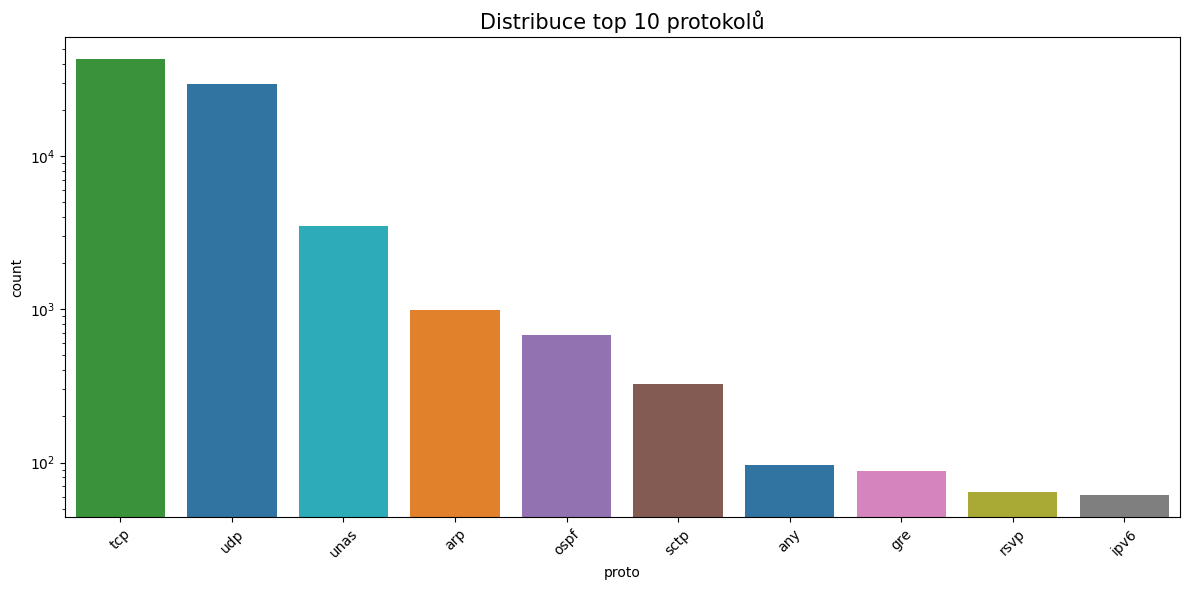

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
top_10_order = df_training['proto'].value_counts().nlargest(10).index #

ax = sns.countplot( 
    data=df_training, 
    x='proto', 
    order=top_10_order, 
    hue='proto',
    palette="tab10", 
    legend=False
)

plt.title('Distribuce top 10 protokolů', fontsize=15)
ax.set_yscale("log") 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

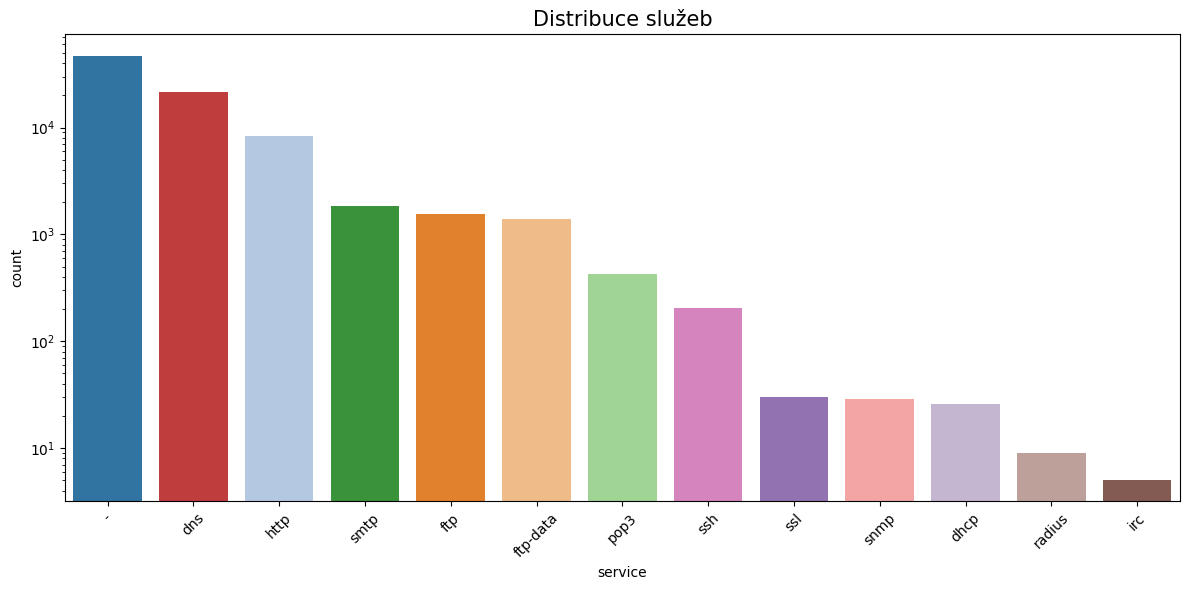

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

all_order = df_training['service'].value_counts().index
ax = sns.countplot(
    data=df_training, 
    x='service', 
    order=all_order, 
    hue='service',
    palette="tab20", 
    legend=False
)

plt.title('Distribuce služeb', fontsize=15)
ax.set_yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Protože pro MLS je třeba použít one-hot encoding. Počty unikátních hodnot jako 131 jsou krajně nežádoucí.

Na základě výšše uvedených grafů jsem se rozhodl ponechat jen 6 protokolů a zbytek přiřadit do skupiny others.

Obdobně ponechat jen 8 služeb a zbytek přiřadit do skupiny others.

In [14]:
#Replacing proto
top_protos = df_training['proto'].value_counts().nlargest(6).index
df_training['proto'] = df_training['proto'].apply(lambda x: x if x in top_protos else 'others')
df_training['proto'].unique()

array(['udp', 'arp', 'tcp', 'others', 'ospf', 'sctp', 'unas'],
      dtype=object)

In [15]:
#Replacing service
top_services = df_training['service'].value_counts().nlargest(6).index
df_training['service'] = df_training['service'].apply(lambda x: x if x in top_services else 'others')
df_training['service'].unique()

array(['-', 'http', 'ftp', 'ftp-data', 'smtp', 'others', 'dns'],
      dtype=object)

## Encoding
* rovnou pro DT, Naive Bayes a MLP
* nominal na one-hot encoding
* power transform pro těžce nakloněná data
* scaling pro zbytek

In [16]:
df_training_enc = df_training

In [17]:
df_numericals = df_training_enc.select_dtypes(include=['int', 'float'])

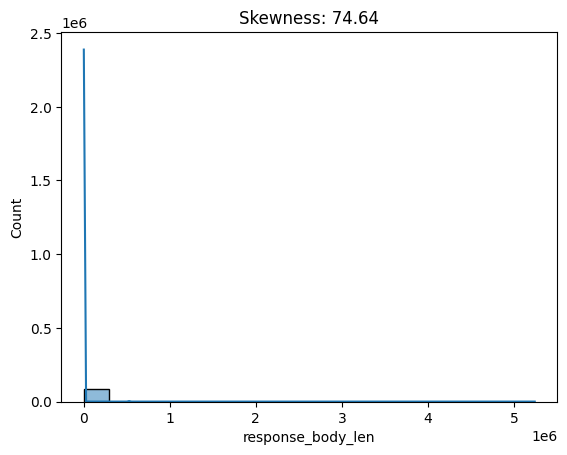

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_numericals['response_body_len'], kde=True)
plt.title(f"Skewness: {df_numericals['response_body_len'].skew():.2f}")
plt.show()

In [19]:
df_numericals['response_body_len'] = df_training_enc['response_body_len']
df_numericals['response_body_len'] = df_numericals['response_body_len'].clip(upper=df_numericals['response_body_len'].quantile(0.93))
df_numericals['response_body_len'].unique() 

array([0])

In [20]:
df_numericals['response_body_len'] = (df_numericals['response_body_len'] > 0).astype(int)

Protože PowerTransformer si není schopen s těmito daty poradit a pouhých zhruba 7% dat není 0. Rozhodl jsem se tedy sloupec převést na binární, kde větší než 0 bude 1 a 0 bude 0.

In [21]:
bin_cols = [
    col for col in df_numericals.columns
    if df_numericals[col].nunique() == 2
]
df_numericals[bin_cols].columns

Index(['is_sm_ips_ports', 'label'], dtype='object')

In [22]:
low_unq_cols = [
    col for col in df_numericals.columns
    if (df_numericals[col].nunique() >= 3 and df_numericals[col].nunique() <= 8) 
]
df_numericals[low_unq_cols].columns

Index(['dttl', 'trans_depth', 'ct_state_ttl', 'is_ftp_login', 'ct_ftp_cmd',
       'ct_flw_http_mthd'],
      dtype='object')

In [23]:
high_unq_cols = [
    col for col in df_numericals.columns
    if (df_numericals[col].nunique() > 8) 
]
df_numericals[high_unq_cols].columns

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'sload',
       'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin',
       'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst'],
      dtype='object')

In [24]:
skewness_score = df_numericals[high_unq_cols].skew()
skewed_cols = [
    col for col in skewness_score.index 
    if (skewness_score[col] > 1 or skewness_score[col] < -1) 
    and df_numericals[col].nunique() > 2
]
df_numericals[skewed_cols].skew()

dur                  9.523750
spkts               47.747777
dpkts               49.304127
sbytes              53.778546
dbytes              52.550387
rate                 3.499493
sload                9.488393
dload                4.753901
sloss               52.465277
dloss               54.465649
sinpkt               9.274082
dinpkt              23.013046
sjit                15.349380
djit                60.562275
tcprtt               9.060344
synack              13.809682
ackdat               9.628722
smean                3.544111
dmean                3.106839
ct_srv_src           1.856368
ct_dst_ltm           2.667001
ct_src_dport_ltm     2.856818
ct_dst_sport_ltm     2.506801
ct_dst_src_ltm       2.189041
ct_src_ltm           2.437292
ct_srv_dst           1.898853
dtype: float64

In [25]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(method='yeo-johnson')
transformed_data = pd.DataFrame(
    power_transformer.fit_transform(df_numericals[skewed_cols]),
    columns=skewed_cols,
    index=df_numericals.index
)

df_numericals[skewed_cols] = transformed_data
df_numericals[skewed_cols].skew()

dur                 0.605473
spkts               0.238677
dpkts               0.176442
sbytes              0.135926
dbytes              0.085667
rate               -0.016381
sload              -0.056383
dload               0.088511
sloss               0.266139
dloss               0.456529
sinpkt              0.317404
dinpkt              0.448185
sjit                0.154696
djit                0.324051
tcprtt              0.746513
synack              0.851046
ackdat              0.746061
smean               0.350768
dmean               0.032025
ct_srv_src          0.072541
ct_dst_ltm          0.271877
ct_src_dport_ltm    0.576981
ct_dst_sport_ltm    0.863560
ct_dst_src_ltm      0.281142
ct_src_ltm          0.192168
ct_srv_dst          0.098030
dtype: float64

In [26]:
to_standard_scale_cols = [
    col for col in high_unq_cols
    if col not in skewed_cols
]
to_standard_scale_cols

['sttl', 'swin', 'stcpb', 'dtcpb', 'dwin']

In [27]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
df_numericals[to_standard_scale_cols] = standard_scaler.fit_transform(df_numericals[to_standard_scale_cols])
df_numericals[to_standard_scale_cols].skew()

sttl    -0.690381
swin    -0.093574
stcpb    0.916447
dtcpb    0.930137
dwin    -0.012329
dtype: float64

In [28]:
from sklearn.preprocessing import OneHotEncoder
LUQ_OHE_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas") #rets pandas Dataframe
df_temp = LUQ_OHE_encoder.fit_transform(df_numericals[low_unq_cols])

#concating encoded data back into numericals
df_numericals = pd.concat([
    df_numericals.drop(columns=low_unq_cols), 
    df_temp
], axis=1)

In [29]:
for c in nominal_cols:
    print(f"Unikátní hodnoty sloupce {c}:")
    print(df_training_enc[c].unique())
    cnt = len(df_training_enc[c].unique())
    print(f"Počet unikátních hodnot: {cnt}")

Unikátní hodnoty sloupce proto:
['udp' 'arp' 'tcp' 'others' 'ospf' 'sctp' 'unas']
Počet unikátních hodnot: 7
Unikátní hodnoty sloupce state:
['INT' 'FIN' 'REQ' 'ACC' 'CON' 'RST' 'CLO']
Počet unikátních hodnot: 7
Unikátní hodnoty sloupce service:
['-' 'http' 'ftp' 'ftp-data' 'smtp' 'others' 'dns']
Počet unikátních hodnot: 7


In [30]:
#one-hot encoding
LBL_OHE_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
cols_to_encode = ['proto', 'state', 'service']

df_ohe = LBL_OHE_encoder.fit_transform(df_training_enc[cols_to_encode])

In [31]:
df_training_enc = pd.concat([df_numericals, df_ohe], axis=1)

In [32]:
df_training_enc

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,response_body_len,ct_srv_src,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,dttl_0,dttl_29,dttl_30,dttl_31,dttl_32,dttl_60,dttl_252,dttl_253,trans_depth_0,trans_depth_1,trans_depth_2,trans_depth_3,trans_depth_4,trans_depth_8,trans_depth_9,trans_depth_131,ct_state_ttl_0,ct_state_ttl_1,ct_state_ttl_2,ct_state_ttl_3,ct_state_ttl_4,ct_state_ttl_5,ct_state_ttl_6,is_ftp_login_0,is_ftp_login_1,is_ftp_login_2,ct_ftp_cmd_0,ct_ftp_cmd_1,ct_ftp_cmd_2,ct_flw_http_mthd_0,ct_flw_http_mthd_1,ct_flw_http_mthd_2,ct_flw_http_mthd_4,ct_flw_http_mthd_6,ct_flw_http_mthd_9,ct_flw_http_mthd_12,ct_flw_http_mthd_16,proto_arp,proto_ospf,proto_others,proto_sctp,proto_tcp,proto_udp,proto_unas,state_ACC,state_CLO,state_CON,state_FIN,state_INT,state_REQ,state_RST,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_others,service_smtp
0,-0.842305,-0.979902,-1.048670,0.135652,-1.074349,0.948125,0.719440,1.240160,-1.069247,-0.984355,-0.917774,-0.939098,-0.861816,-0.991122,-0.912811,-1.047920,-0.779840,-0.776754,-1.006244,-0.726621,-0.704298,-0.722800,1.573909,-1.084644,0,-0.910311,-1.157463,-0.863395,-0.698466,-0.365794,-1.279148,-0.806418,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.842321,-0.979902,-1.048670,0.897823,-1.074349,1.027641,0.719440,1.667212,-1.069247,-0.984355,-0.917774,-0.941336,-0.861816,-0.991122,-0.912811,-1.047920,-0.779840,-0.776754,-1.006244,-0.726621,-0.704298,-0.722800,1.962424,-1.084644,0,-0.910311,-1.157463,-0.863395,-0.698466,-0.365794,-1.279148,-0.806418,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.842337,-0.979902,-1.048670,0.626319,-1.074349,1.145338,0.719440,1.658756,-1.069247,-0.984355,-0.917774,-0.943584,-0.861816,-0.991122,-0.912811,-1.047920,-0.779840,-0.776754,-1.006244,-0.726621,-0.704298,-0.722800,1.871846,-1.084644,0,-0.529585,-1.157463,-0.863395,-0.698466,0.075437,-1.279148,-0.424328,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.842332,-0.979902,-1.048670,0.525115,-1.074349,1.099633,0.719440,1.561839,-1.069247,-0.984355,-0.917774,-0.942834,-0.861816,-0.991122,-0.912811,-1.047920,-0.779840,-0.776754,-1.006244,-0.726621,-0.704298,-0.722800,1.826459,-1.084644,0,-0.529585,-0.288038,0.176116,-0.698466,0.075437,-0.502471,-0.424328,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.842310,-0.979902,-1.048670,0.990892,-1.074349,0.971904,0.719440,1.657462,-1.069247,-0.984355,-0.917774,-0.939843,-0.861816,-0.991122,-0.912811,-1.047920,-0.779840,-0.776754,-1.006244,-0.726621,-0.704298,-0.722800,1.984799,-1.084644,0,-0.529585,-0.288038,0.176116,-0.698466,0.075437,-0.502471,-0.424328,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

## x - features and y - target split

In [33]:
X_train = df_training_enc.drop(columns=['label'])
y_train = df_training_enc['label']

print(X_train.shape)
print(y_train.shape)

(82332, 91)
(82332,)


## Obdobný proces pro target data
* zahodit id a attack_cat
* rozdělit na nominální, numerické a binární hodnoty
* nominální snížit počet kategorií skrze novou kategorii others a převést na numerické hodnoty skrze one-hot-encoding
* numerické rozdělit na ty s nízkým počtem unikátních hodnot => OHE a na ty s vysokým počtem hodnot => powertransform pro těžce nakloněné a potom standardscaler pro normalizaci
* binární ponechat
* následně rozdělit na X_test a y_test

In [34]:
#Data loading from 'CHY0092_P2/UNSW_NB15_testing-set.csv'
df_test = pd.read_csv('CHY0092_P2/UNSW_NB15_testing-set.csv')
df_test.head()
df_test.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [35]:
df_test.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [36]:
df_training.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')

In [37]:
mismatch_cols = [c for c in df_test.columns if c not in df_training.columns]
mismatch_cols

['id', 'attack_cat']

In [38]:
#discarding cols
df_test.drop(columns=['id', 'attack_cat'], inplace=True)

In [39]:
#replacing proto again
top_protos = df_test['proto'].value_counts().nlargest(6).index
df_test['proto'] = df_test['proto'].apply(lambda x: x if x in top_protos else 'others')
df_test['proto'].unique()

array(['tcp', 'udp', 'arp', 'ospf', 'others', 'unas', 'sctp'],
      dtype=object)

In [40]:
#replacing service again
top_services = df_test['service'].value_counts().nlargest(6).index
df_test['service'] = df_test['service'].apply(lambda x: x if x in top_services else 'others')
df_test['service'].unique()

array(['-', 'ftp', 'smtp', 'others', 'http', 'ftp-data', 'dns'],
      dtype=object)

In [41]:
#encoding start of test data
df_test_enc = df_test

In [42]:
mismatch_numericals = [c for c in df_test.select_dtypes(include=['int', 'float']) if c not in df_training.select_dtypes(include=['int', 'float'])]
mismatch_numericals

[]

In [43]:
df_numericals = df_test_enc.select_dtypes(include=['int', 'float'])

In [44]:
df_numericals['response_body_len'] = df_test_enc['response_body_len']
df_numericals['response_body_len'] = df_numericals['response_body_len'].clip(upper=df_numericals['response_body_len'].quantile(0.93))
df_numericals['response_body_len'].unique() 

array([0])

In [45]:
#bin transform of response_body_len
df_numericals['response_body_len'] = (df_numericals['response_body_len'] > 0).astype(int)

In [46]:
transformed_data = pd.DataFrame(
    power_transformer.fit_transform(df_numericals[skewed_cols]),
    columns=skewed_cols,
    index=df_numericals.index
)

df_numericals[skewed_cols] = transformed_data
df_numericals[skewed_cols].skew()

dur                 0.777277
spkts               0.315238
dpkts               0.251113
sbytes              0.175237
dbytes              0.158917
rate               -0.095572
sload              -0.112125
dload               0.157973
sloss               0.402438
dloss               0.557750
sinpkt              0.453504
dinpkt              0.577926
sjit                0.280509
djit                0.427777
tcprtt              0.992152
synack              1.093927
ackdat              0.996928
smean               0.329638
dmean               0.114349
ct_srv_src          0.110524
ct_dst_ltm          0.280830
ct_src_dport_ltm    0.608095
ct_dst_sport_ltm    0.791917
ct_dst_src_ltm      0.205050
ct_src_ltm          0.194097
ct_srv_dst          0.133411
dtype: float64

In [47]:
df_numericals[to_standard_scale_cols] = standard_scaler.fit_transform(df_numericals[to_standard_scale_cols])
df_numericals[to_standard_scale_cols].skew()

sttl    -0.678109
swin     0.177048
stcpb    1.081121
dtcpb    1.081017
dwin     0.196820
dtype: float64

In [48]:
df_temp = LUQ_OHE_encoder.transform(df_numericals[low_unq_cols])

df_numericals = pd.concat([
    df_numericals.drop(columns=low_unq_cols), 
    df_temp
], axis=1)

In [49]:
enc_data = LBL_OHE_encoder.transform(df_test_enc[cols_to_encode])

df_ohe = pd.DataFrame(
    enc_data, 
    columns=LBL_OHE_encoder.get_feature_names_out(cols_to_encode),
    index=df_training_enc.index
)

In [50]:
df_test_enc = pd.concat([df_numericals, df_ohe], axis=1)

In [51]:
X_test = df_test_enc.drop(columns=['label'])
y_test = df_test_enc['label']

print(X_test.shape)
print(y_test.shape)

(175341, 91)
(175341,)


In [52]:
print(X_train.shape)
print(y_train.shape)

(82332, 91)
(82332,)


In [53]:
print(df_test_enc.columns)
print(df_training_enc.columns)

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'sload',
       'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin',
       'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'response_body_len', 'ct_srv_src', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label', 'dttl_0', 'dttl_29',
       'dttl_30', 'dttl_31', 'dttl_32', 'dttl_60', 'dttl_252', 'dttl_253',
       'trans_depth_0', 'trans_depth_1', 'trans_depth_2', 'trans_depth_3',
       'trans_depth_4', 'trans_depth_8', 'trans_depth_9', 'trans_depth_131',
       'ct_state_ttl_0', 'ct_state_ttl_1', 'ct_state_ttl_2', 'ct_state_ttl_3',
       'ct_state_ttl_4', 'ct_state_ttl_5', 'ct_state_ttl_6', 'is_ftp_login_0',
       'is_ftp_login_1', 'is_ftp_login_2', 'ct_ftp_cmd_0', 'ct_ftp_cmd_1',
       'ct_ftp_cmd_2', 'ct_flw_http_mthd_0', 'ct_flw_http_mthd_1',
       'ct_flw_http_mthd_2', 'ct

In [54]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [55]:
not_possible = [
    c for c in df_training_enc.columns if c not in df_test_enc.columns
]
print(not_possible)

[]


Vzhledem k tomu že většina provozu na síťi by neměla být útokem, rozhodl jsem se pro F1 skóre jako metriku, která je vhodná pro těžce vychýlená data.

## Decision Tree

In [56]:
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
dt_clf = DecisionTreeClassifier(random_state=13, class_weight='balanced')

hyperparams = {
    'min_samples_split' : randint(2, 50), #def (and min) is 2
    'max_depth' : randint(1, 25), #def is None
    'min_samples_leaf' : randint(1, 30) #def is 1
}

dt_search = RandomizedSearchCV(
    estimator = dt_clf,
    param_distributions = hyperparams,
    n_iter = 20, #how many random settings to try
    cv = 5, #hould be def, how many folds, should use Stratified due to binary or
    scoring = 'f1',
    random_state = 13,
    n_jobs = -1 #use all available processors
)

dt_search.fit(X_train, y_train)
print(f"Best f1: {dt_search.best_score_}")
print(f"Best params: {dt_search.best_params_}")

#test result on clean data
best_dt_clf = dt_search.best_estimator_
y_pred_best = best_dt_clf.predict(X_test)
best_f1 = f1_score(y_test, y_pred_best)

print(f"Best DT f1 score: {best_f1}")

Best f1: 0.9477081323766491
Best params: {'max_depth': 12, 'min_samples_leaf': 21, 'min_samples_split': 4}
Best DT f1 score: 0.8489303231970636


## Naive Bayes

In [57]:
from sklearn.naive_bayes import GaussianNB
from scipy.stats import loguniform

nb_clf = GaussianNB()

hyperparams = {
    'var_smoothing': loguniform(1e-11, 1e-1) #very small real number tend to perform better
}

nb_search = RandomizedSearchCV(
    estimator = nb_clf,
    param_distributions = hyperparams,
    n_iter = 5, #how many random settings to try
    cv = 5, #hould be def, how many folds, should use Stratified due to binary or
    scoring = 'f1',
    random_state = 13,
    n_jobs = -1 #use all available processors
)

nb_search.fit(X_train, y_train)
print(f"Best f1: {nb_search.best_score_}")
print(f"Best params: {nb_search.best_params_}")

#test result on clean data
best_nb_clf = nb_search.best_estimator_
y_pred_best = best_nb_clf.predict(X_test)
best_f1 = f1_score(y_test, y_pred_best)

print(f"Best NB f1 score: {best_f1}")

Best f1: 0.7770526116890734
Best params: {'var_smoothing': np.float64(2.373625507453875e-09)}
Best NB f1 score: 0.7792240237839458


## MLP

In [58]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(max_iter=500, random_state=13) 

hyperparams = {
    #1 layer of 50, 1 of 100, or 2 layers (50, 25)
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': loguniform(1e-5, 1e-1),
    'learning_rate_init': loguniform(1e-6, 1e-1)
}

mlp_search = RandomizedSearchCV(
    estimator = mlp_clf,
    param_distributions = hyperparams,
    n_iter = 10, #MLP training too slow, hence the small n_iter
    cv = 3, #also reduced to 3 to make the process faster
    scoring = 'f1',
    random_state = 13,
    n_jobs = -1 #use all available processors
)

mlp_search.fit(X_train, y_train)

print(f"Best f1: {mlp_search.best_score_}")
print(f"Best Parameters: {mlp_search.best_params_}")

best_mlp = mlp_search.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)
print(f"Final MLP Test F1: {f1_score(y_test, y_pred_mlp)}")

/home/petr/JupyterNotebookEnv/jupyter_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petr/JupyterNotebookEnv/jupyter_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Best f1: 0.9227082078424725
Best Parameters: {'activation': 'tanh', 'alpha': np.float64(0.0009727950104609384), 'hidden_layer_sizes': (100, 50), 'learning_rate_init': np.float64(1.9116119935076432e-05), 'solver': 'adam'}
Final MLP Test F1: 0.852017129118078


## Závěr
Multi-Layer Perceptons má nejlepší F1 skóre, cca 0.852, následování Decision Tree s 0.849 a poslední je Gaussian Naive Bayes s 0.799.
Varování k MLP upozorňuje na potenciál pro zlepšení omezený maximálním počtem iterací. Skóre by se pravděpodobně dala zlepšit více iteracemi při hledání optimálních hyperparametrů, zde jsem ale limitován hardwarem a ochotou čekat na výsledky.

Petr Chyla, CHY0092